In [1]:
import torch
import Emulator.Models.misc as misc
#get the emulator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# file_string = "/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20260115_162421-yenwccx3/files/checkpoint_last.p"
# file_string = "/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20260126_144324-ajfjvm72/files/checkpoint_best.p"
file_string = "/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20260128_025723-qbx6gf4w/files/checkpoint_best.p"
emu=misc.load_model(file_string).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/Emulator/Models/misc.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [2]:
from tqdm import tqdm
data_dict = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/long_qg_rollouts.pt")

data = data_dict["data"]
del data_dict

/state/partition1/job-4388264/ipykernel_82754/2232996680.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/long_q

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
upper_std=7.6382e-06
lower_std=3.0120e-07

if len(data.shape)==5:
    data[:,:,0,:,:]/=upper_std
    data[:,:,1,:,:]/=lower_std
else:
    data[:,0,:,:]/=upper_std
    data[:,1,:,:]/=lower_std
print(data.shape)

torch.Size([5, 50000, 2, 64, 64])


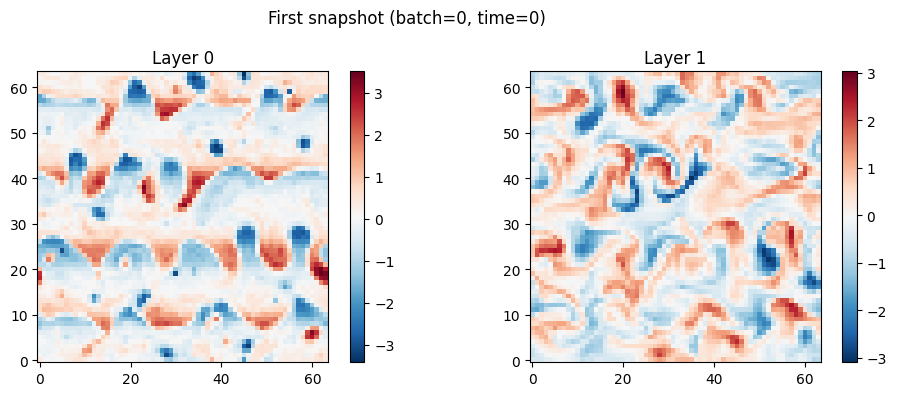

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for layer in [0, 1]:
    img = data[-1, 0, layer].detach().cpu().numpy()
    im = axes[layer].imshow(
        img,
        origin="lower",
        cmap="RdBu_r",   # <-- set colormap here
    )
    axes[layer].set_title(f"Layer {layer}")
    plt.colorbar(im, ax=axes[layer], fraction=0.046)

plt.suptitle("First snapshot (batch=0, time=0)")
plt.tight_layout()
plt.show()


In [5]:
import torch
import CT.Models.misc as misc
import CT.Inference.TLQG.performance as performance
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SNS_QG_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260124_220044-2c2x4ojw/files/checkpoint_last.p"

SNS_QG_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260312_191935-gefi73q9/files/checkpoint_last.p"
SNS_QG = misc.load_SNS(SNS_QG_file_path).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [6]:
lag_ratio = 1
x = data[0:1].to(device)
x_t = x[:,-1:]
short_lag = torch.tensor([1]).to(device)
long_lag = torch.tensor([99]).to(device)
x_short = x[:,-(short_lag * lag_ratio)-1:-(short_lag * lag_ratio)].to(device)
x_long = x[:,-(long_lag * lag_ratio)-1:-(long_lag * lag_ratio)].to(device)
s_short = 30
x_short = SNS_QG._forward_diffusion(x_short, s_short).to(device)
s_t = 800
x_t_noised = SNS_QG._forward_diffusion(x_t, s_t).to(device)


x_long = SNS_QG._forward_diffusion(x_long, 999).to(device)
x_in = torch.cat((x_long, x_short, x_t_noised),dim = 1)
print(x_in.shape)
x_class = torch.cat((x_long.squeeze(1), x_short.squeeze(1), x_t_noised.squeeze(1)),dim = 1)
pred_s = SNS_QG.model.ratio_class_both(x_class, None, None, long_lag).to(device)
print(pred_s)
denoised = SNS_QG.denoising_left_down(x_in, pred_s, forward_diff = True)

torch.Size([1, 3, 2, 64, 64])
tensor([[ 35, 802]], device='cuda:0')


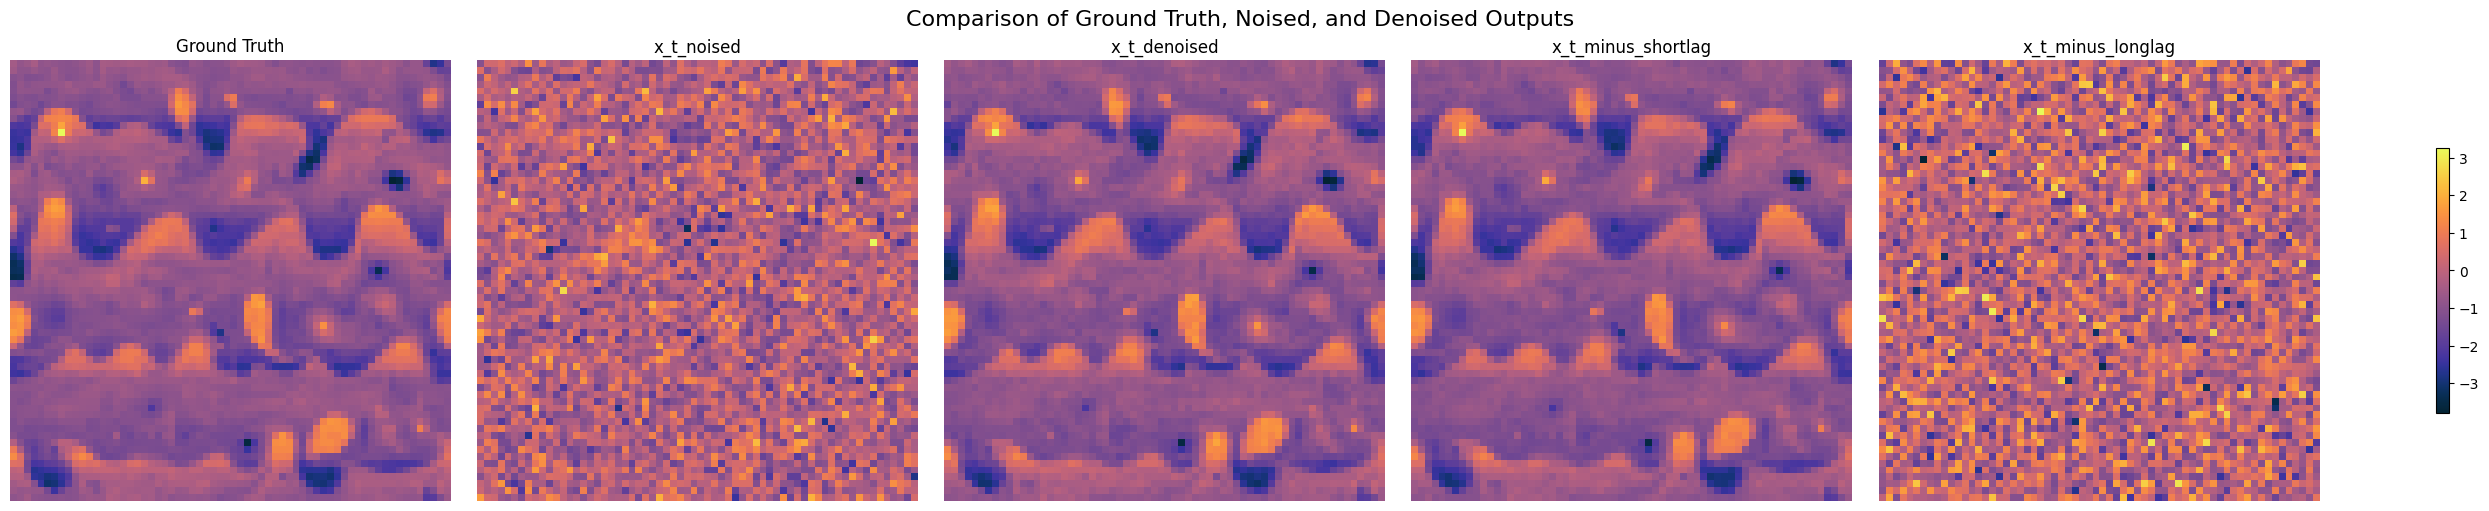

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x_t[:,0,0:1],                
    x_t_noised[:,0,0:1],
    denoised[:,-1,0:1],
    x_short[:,0,0:1],
    x_long[:,0,0:1]
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# SNS_rollout = performance.SNS_QG_refinement(data[:,0].to(device), emu, SNS_QG, n_steps=20000, sigma=1e-4, silence=False,  forward_diff = True, denoise_mode = "left_down", device = "cuda")

In [10]:
SNS_rollout = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/FINAL_PAPER_QG.p")

/state/partition1/job-4388264/ipykernel_82754/1974869793.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  SNS_rollout = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/FINA

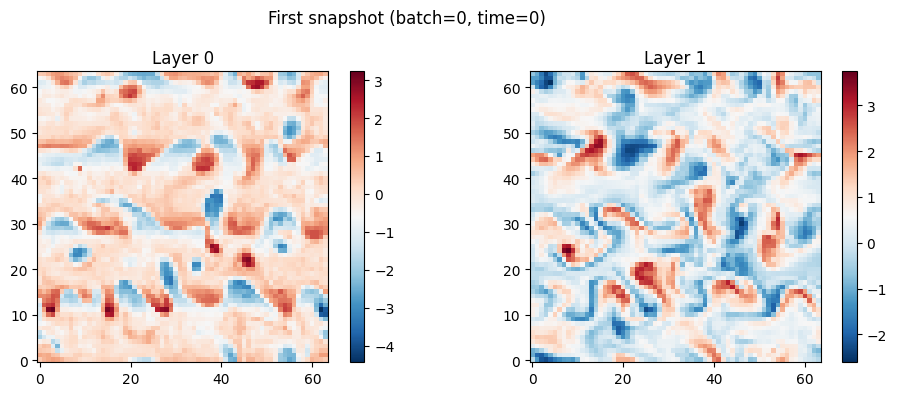

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for layer in [0, 1]:
    img = SNS_rollout[0][0, -1, layer].detach().cpu().numpy()
    im = axes[layer].imshow(
        img,
        origin="lower",
        cmap="RdBu_r",   # <-- set colormap here
    )
    axes[layer].set_title(f"Layer {layer}")
    plt.colorbar(im, ax=axes[layer], fraction=0.046)

plt.suptitle("First snapshot (batch=0, time=0)")
plt.tight_layout()
plt.show()


In [20]:
ics = data[:,0:1]

emu_rollout = performance.run_emu(ics, emu, n_steps=20000, silent=False, sigma = 1e-3)

100%|██████████| 19999/19999 [01:46<00:00, 187.81it/s]


In [21]:
torch.save(emu_rollout, "/scratch/ql2221/PDE_data/2LQG/jet/FINAL_PAPER_QG_EMU.p")

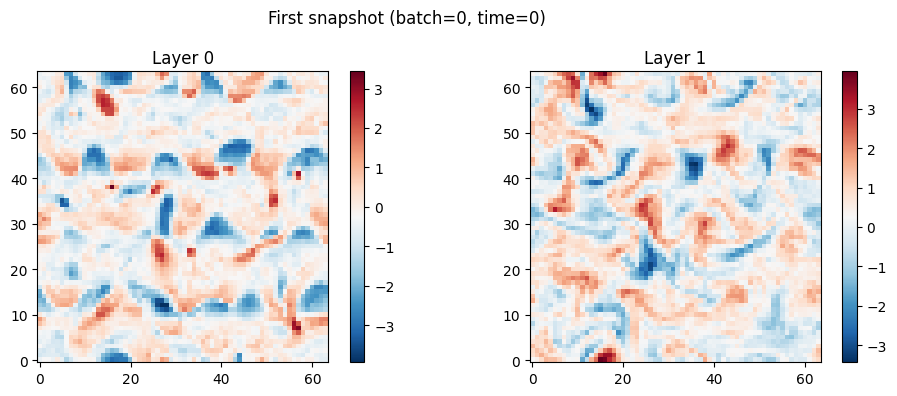

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for layer in [0, 1]:
    img = emu_rollout[0, 1000, layer].detach().cpu().numpy()
    im = axes[layer].imshow(
        img,
        origin="lower",
        cmap="RdBu_r",   # <-- set colormap here
    )
    axes[layer].set_title(f"Layer {layer}")
    plt.colorbar(im, ax=axes[layer], fraction=0.046)

plt.suptitle("First snapshot (batch=0, time=0)")
plt.tight_layout()
plt.show()


In [21]:
import matplotlib.pyplot as plt
from matplotlib import animation
from tqdm import tqdm
import numpy as np
import cmocean

# Option A: use a self-contained ffmpeg (avoids your broken /ext3/miniforge3/bin/ffmpeg)
import matplotlib as mpl
import imageio_ffmpeg as iio

def make_movie_2layer_qg(state_vector, save_path="qg2layer_movie.mp4", fps=30,
                         vmin=-4, vmax=4, stride=10,
                         layer_titles=("Layer 1", "Layer 2"),
                         share_colorbar_within_layer=True):
    """
    Create an MP4 movie from a 5D tensor of shape (B, T, 2, H, W) for 2-layer QG.

    Uses cmocean's white-red-blue diverging colormap (cmocean.cm.balance).

    Encoding:
      - Uses imageio-ffmpeg to supply a working ffmpeg binary inside Singularity.
      - Uses MPEG-4 Part 2 (codec='mpeg4') to avoid libx264 requirements.
    """

    # Point Matplotlib to the imageio-provided ffmpeg binary
    mpl.rcParams["animation.ffmpeg_path"] = iio.get_ffmpeg_exe()

    B, T, L, H, W = state_vector.shape
    assert L == 2, f"Expected 2 layers, got {L}"

    data = state_vector.detach().cpu().numpy() if hasattr(state_vector, "detach") else np.asarray(state_vector)
    frame_indices = list(range(0, T, stride))

    def _as_per_layer(x):
        if x is None:
            return [None, None]
        if np.isscalar(x):
            return [x, x]
        if len(x) == 2:
            return list(x)
        raise ValueError("vmin/vmax must be None, a scalar, or a length-2 tuple/list.")

    vmin_L = _as_per_layer(vmin)
    vmax_L = _as_per_layer(vmax)

    # If limits not provided, use symmetric limits per layer (common for QG fields)
    for l in range(2):
        if vmin_L[l] is None or vmax_L[l] is None:
            m = float(np.nanmax(np.abs(data[:, :, l])))
            vmin_L[l] = -m
            vmax_L[l] =  m

    fig, axes = plt.subplots(B, 2, figsize=(10, 4.5 * B), squeeze=False)

    ims = [[None, None] for _ in range(B)]
    for b in range(B):
        for l in range(2):
            ax = axes[b, l]
            im = ax.imshow(
                data[b, 0, l],
                cmap=cmocean.cm.balance,
                vmin=vmin_L[l],
                vmax=vmax_L[l],
                origin="upper",
            )
            ax.set_title(f"Batch {b} — {layer_titles[l]} — Timestep 0")
            ax.set_xticks([])
            ax.set_yticks([])
            ims[b][l] = im

    # Colorbars
    if share_colorbar_within_layer:
        for l in range(2):
            fig.colorbar(ims[0][l], ax=axes[:, l].ravel().tolist(), shrink=0.9)
    else:
        for b in range(B):
            for l in range(2):
                fig.colorbar(ims[b][l], ax=axes[b, l], shrink=0.9)

    def frame_generator():
        for i in tqdm(range(len(frame_indices)), desc="Building frames"):
            yield i

    def update(frame_idx):
        t = frame_indices[frame_idx]
        artists = []
        for b in range(B):
            for l in range(2):
                ims[b][l].set_data(data[b, t, l])
                axes[b, l].set_title(f"Batch {b} — {layer_titles[l]} — Timestep {t}")
                artists.append(ims[b][l])
        return artists

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=frame_generator(),
        blit=False,
        repeat=False
    )

    # Use MPEG-4 Part 2 (no x264), with the working ffmpeg from imageio-ffmpeg
    Writer = animation.writers["ffmpeg"]
    writer = Writer(
        fps=fps,
        codec="mpeg4",
        bitrate=20000,
        extra_args=["-pix_fmt", "yuv420p"]
    )

    ani.save(save_path, writer=writer)
    plt.close(fig)
    print("movie saved:", save_path)


In [22]:
make_movie_2layer_qg(emu_rollout[:,::100], save_path="qg_emu.mp4", stride=1, fps=30)


/state/partition1/job-1244075/ipykernel_3316503/1138641800.py:94: UserWarning: frames=<generator object make_movie_2layer_qg.<locals>.frame_generator at 0x1478f8c15b70> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(
Building frames: 100%|██████████| 200/200 [00:36<00:00,  5.48it/s]

movie saved: qg_emu.mp4


In [ ]:
make_movie_2layer_qg(SNS_rollout[:,::10], save_path="qg_SNS.mp4", stride=1, fps=30)

In [44]:
import torch

@torch.no_grad()
def k_step_then_tweedie(SNS_QG, x_short, x_long, t=999, k=10):
    """
    Forward-noise x_short to level t, take k reverse DDPM steps (keeping long & short fixed),
    then apply Tweedie's formula to estimate x0 from x_{t-k}.

    Uses the same concatenation logic as your original one_shot:
      x_long, x_short, x_t are [B,2,H,W]
      x_conditional = [B,6,H,W] = [long(2), short(2), t(2)]
      model(...) returns a tensor with at least the last-2 channels corresponding to t-noise.
    """
    device = x_long.device
    B = x_long.shape[0]

    k = int(k)
    t = int(t)
    k = min(k, t)

    # 1) Forward diffuse short to get x_t at level t (shape [B,2,H,W])
    x_t = SNS_QG._forward_diffusion(x_short, t).to(device)

    # Pack conditional: [B,6,H,W]
    x_conditional = torch.cat((x_long, x_short, x_t), dim=1)

    # 2) k reverse steps: t -> t-1 -> ... -> t-k
    for i in range(t, t - k, -1):
        s = torch.full((B,), i, device=device, dtype=torch.int64)

        # Split blocks (each [B,2,H,W])
        x_t_curr   = x_conditional[:, -2:]
        x_shortlag = x_conditional[:, -4:-2]
        x_longlag  = x_conditional[:, -6:-4]

        # Predict noise for the t-block (must be [B,2,H,W])
        pred_x_t_noise = SNS_QG.model(x_conditional, None, None, None, False)[:, -2:]

        # DDPM posterior mean components (broadcast over [B,2,H,W])
        alpha_s = SNS_QG.alphas.gather(-1, s).view(B, 1, 1, 1)
        alpha_bar_s = SNS_QG.alphas_cumprod.gather(-1, s).view(B, 1, 1, 1)
        beta_s = SNS_QG.betas.gather(-1, s).view(B, 1, 1, 1)
        sqrt_one_minus_alpha_bar_s = SNS_QG.sqrt_one_minus_alphas_cumprod.gather(-1, s).view(B, 1, 1, 1)

        mean_t = (1.0 / torch.sqrt(alpha_s)) * (
            x_t_curr - ((1.0 - alpha_s) / sqrt_one_minus_alpha_bar_s) * pred_x_t_noise
        )

        # Sample x_{s-1} for the t-block
        if i > 0:
            s_prev = s - 1
            alpha_bar_prev = SNS_QG.alphas_cumprod.gather(-1, s_prev).view(B, 1, 1, 1)
            std = torch.sqrt(beta_s * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_s))
            z = torch.randn_like(x_t_curr)
            x_t_next = mean_t + std * z
        else:
            x_t_next = mean_t

        # Re-pack conditional for next step (keep long/short fixed)
        x_conditional = torch.cat((x_longlag, x_shortlag, x_t_next), dim=1)

    # We are now at s_final = t-k
    s_final = t - k
    x_tk = x_conditional[:, -2:]  # x_{t-k}, shape [B,2,H,W]

    # 3) Tweedie step at s_final
    s_vec = torch.full((B,), s_final, device=device, dtype=torch.int64)
    a_bar = SNS_QG.alphas_cumprod.gather(-1, s_vec).view(B, 1, 1, 1)

    pred_noise_final = SNS_QG.model(x_conditional, None, None, None, False)[:, -2:]  # [B,2,H,W]
    x0_hat = (x_tk - torch.sqrt(1.0 - a_bar) * pred_noise_final) / torch.sqrt(a_bar)

    # Match your original "out" pattern: concatenate (x_{t-k}, x0_hat) along channels -> [B,4,H,W]
    out = torch.cat((x_tk, x0_hat), dim=1)
    return out


In [47]:
data = data.to(device)
one = k_step_then_tweedie(SNS_QG, data[:,-2], data[:,0], 999, 500)
one.shape

torch.Size([1, 4, 64, 64])

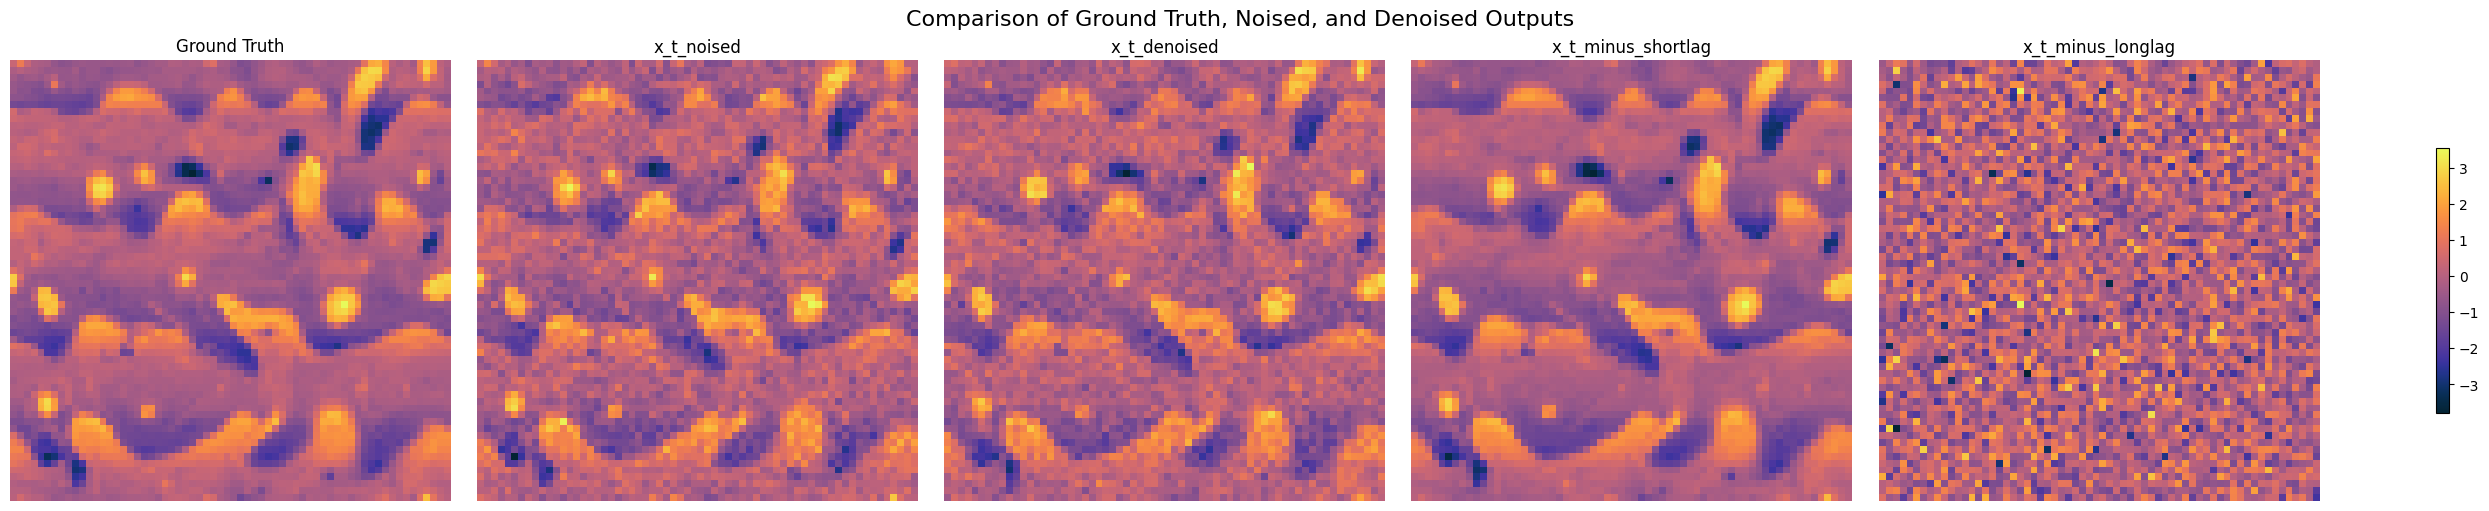

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    data[:,-1,0:1],                
    one[:,-4:-3],
    one[:,-2:-1],
    data[:,-2,0:1],
    x_long[:,0,0:1]
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()

In [24]:
def SNS_QG_gen(ics, emu, SNS, n_steps=1000, short_lag_int = 1, freq = 1, lag_ratio = 1, s_init = 0, starting_time = 1000, sigma=None, silence=False,  forward_diff = True, fix_short = False, device = "cuda"):
    B, C, X, Y = ics.shape
    state_vector=torch.zeros((B,n_steps,C, X,Y),device=device)

    state_vector[:,0]=ics.to(device)
    short_lag = torch.full((B,), short_lag_int, dtype=torch.int64, device=device)
    with torch.no_grad():
        for aa in tqdm(range(1, n_steps), disable=silence):
            prev = state_vector[:, aa - 1]
            pred = one_shot(SNS, prev, ics,200)[:,-2:]
            state_vector[:, aa] = pred

            if sigma is not None:
                state_vector[:, aa] += sigma * torch.randn_like(state_vector[:, aa],device=state_vector[:, aa].device,)
            if aa % freq != 0 or aa - starting_time < 0:
                continue 

            batch_idx = torch.arange(B, device=device)
            x_t_noised = state_vector[:, aa]
            x_t_minus_short_lag = state_vector[:, aa - lag_ratio * short_lag_int]
            
            x_conditional = torch.cat((ics, x_t_minus_short_lag, x_t_noised), dim = 1)
            pred_noise_levels = SNS.model.ratio_class_both(x_conditional, None, None, None).to(device)
            pred_s_t = pred_noise_levels[:,-1:]
            pred_s_short = pred_noise_levels[:,-2:-1]

            mask = (pred_s_t < s_init)
            pred_noise_levels[mask.squeeze(), -2:] = 0

            if pred_s_t.max() > s_init:
                if fix_short:
                    x_conditional = torch.cat((ics.unsqueeze(1), x_t_minus_short_lag.unsqueeze(1), x_t_noised.unsqueeze(1)), dim = 1)
                    state_vector[:, aa] = SNS.denoising_with_fixed_short(x_conditional, pred_noise_levels, forward_diff)[:,-1]
                else:
                    x_conditional = torch.cat((ics.unsqueeze(1), x_t_minus_short_lag.unsqueeze(1), x_t_noised.unsqueeze(1)), dim = 1)
                    combined_vector = SNS.denoising(x_conditional, pred_noise_levels, forward_diff)
                    state_vector[:, aa] = combined_vector[:,-1]
                    state_vector[:,aa-1] = combined_vector[:,-2]
    return state_vector

In [23]:
SNS_rollout = SNS_QG_gen(data[:,0].to(device), emu, SNS_QG, n_steps=1000, short_lag_int = 1, freq = 1, lag_ratio = 1, s_init = 0, starting_time = 1, sigma=1e-4, silence=False,  forward_diff = True, fix_short = False, device = "cuda")

  1%|          | 9/999 [00:00<00:22, 43.55it/s]

tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')


  1%|▏         | 14/999 [00:00<00:25, 38.40it/s]

tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')
tensor([[1]], device='cuda:0')


  2%|▏         | 22/999 [00:00<00:31, 31.41it/s]

...

100%|█████████▉| 996/999 [02:40<00:00,  5.74it/s]

tensor([[10]], device='cuda:0')
tensor([[10]], device='cuda:0')


100%|█████████▉| 998/999 [02:41<00:00,  5.66it/s]

tensor([[10]], device='cuda:0')
tensor([[10]], device='cuda:0')


100%|██████████| 999/999 [02:41<00:00,  6.19it/s]


In [28]:
make_movie_2layer_qg(SNS_rollout[:,::10], save_path="qg_SNS.mp4", stride=1, fps=30)

/state/partition1/job-1185348/ipykernel_3380132/1138641800.py:94: UserWarning: frames=<generator object make_movie_2layer_qg.<locals>.frame_generator at 0x146eda4633d0> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(
Building frames: 100%|██████████| 100/100 [00:20<00:00,  4.83it/s]

movie saved: qg_SNS.mp4


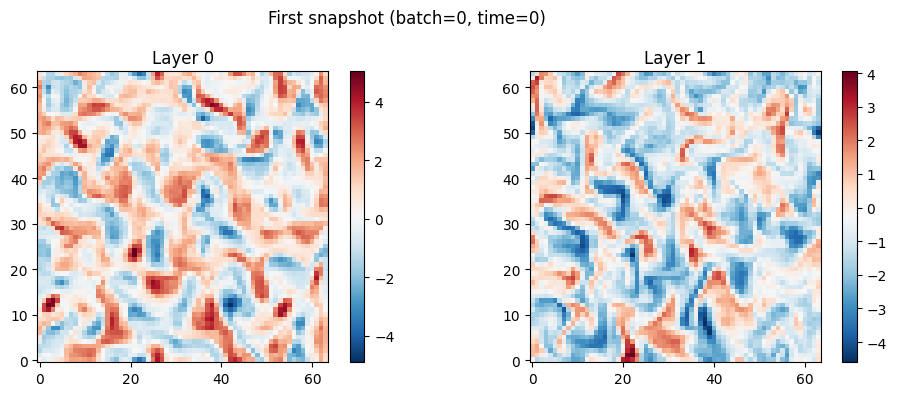

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for layer in [0, 1]:
    img = SNS_rollout[0, -7, layer].detach().cpu().numpy()
    im = axes[layer].imshow(
        img,
        origin="lower",
        cmap="RdBu_r",   # <-- set colormap here
    )
    axes[layer].set_title(f"Layer {layer}")
    plt.colorbar(im, ax=axes[layer], fraction=0.046)

plt.suptitle("First snapshot (batch=0, time=0)")
plt.tight_layout()
plt.show()
